# Load Feature Selection Data

(303, 14)
Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Total missing values: 6
Missing values after imputation: 0
Categorical columns: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Data types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target      float64
dtype: object
Categorical columns: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Numerical columns: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Shape after encoding: (303, 21)
New columns created:
['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target', 'sex_1.0', 'cp_2.0', 'cp_3.0', 'cp_4

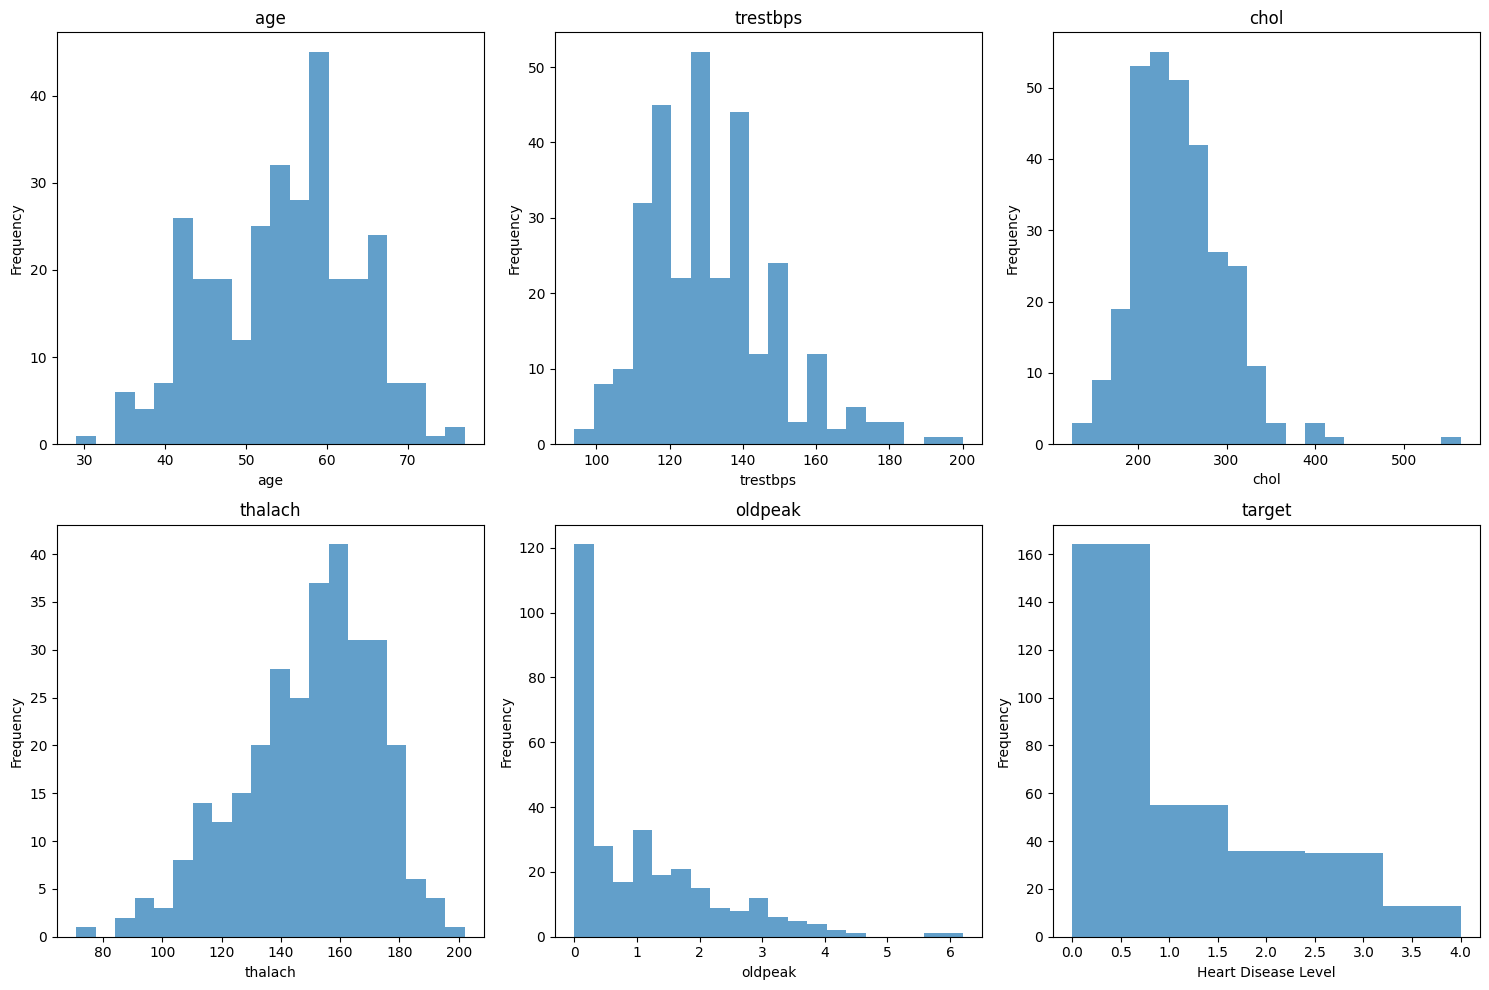

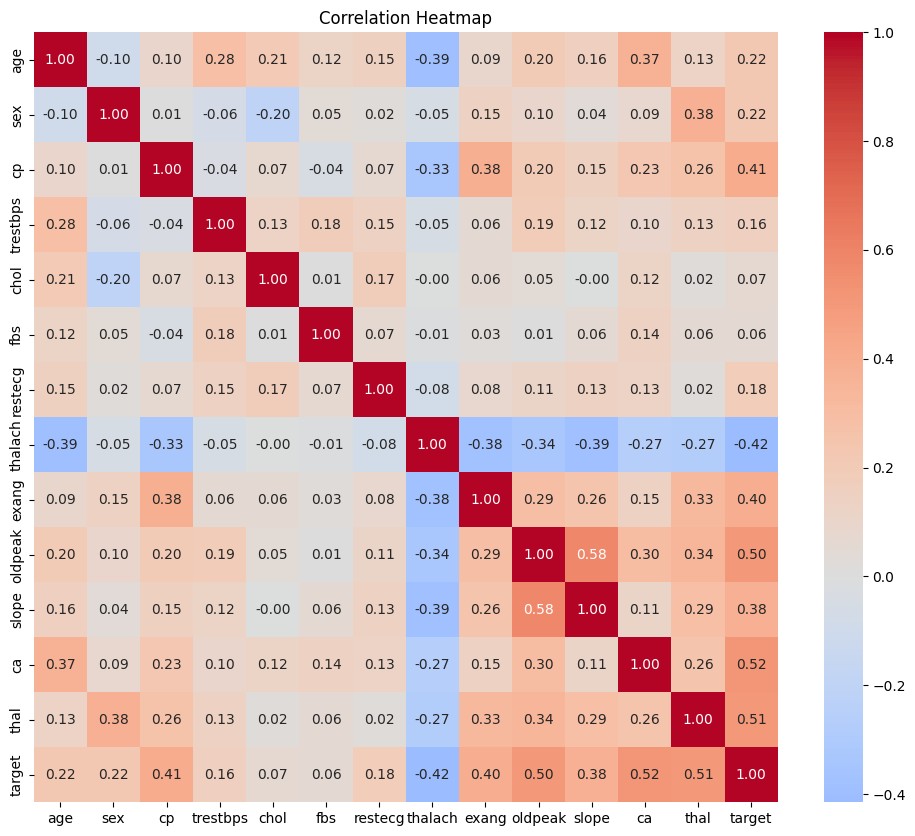

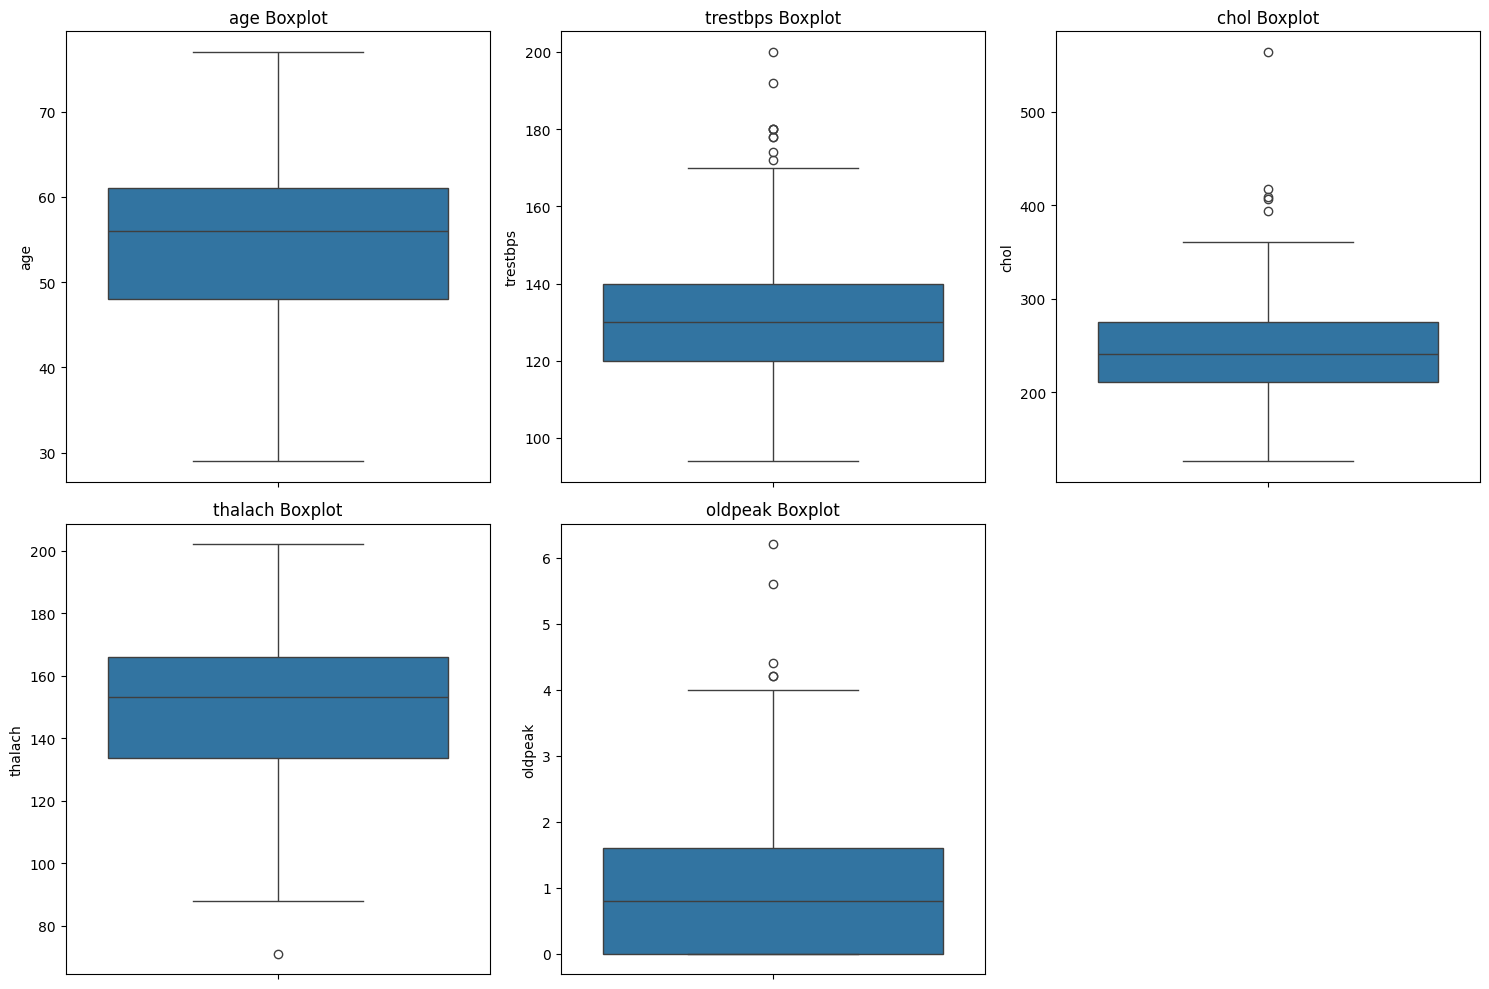

Random Forest Feature Importance:
        feature  importance
3       thalach    0.145161
4       oldpeak    0.119441
0           age    0.114960
2          chol    0.110535
1      trestbps    0.096552
19     thal_7.0    0.060592
8        cp_4.0    0.058923
12    exang_1.0    0.047135
13    slope_2.0    0.034934
15       ca_1.0    0.034681
5       sex_1.0    0.032970
16       ca_2.0    0.031061
11  restecg_2.0    0.024380
17       ca_3.0    0.020094
9       fbs_1.0    0.018563
7        cp_3.0    0.016859
18     thal_6.0    0.012417
6        cp_2.0    0.009235
14    slope_3.0    0.008491
10  restecg_1.0    0.003017
XGBoost Feature Importance:
        feature  importance
8        cp_4.0    0.178133
19     thal_7.0    0.111019
14    slope_3.0    0.110085
15       ca_1.0    0.066373
16       ca_2.0    0.059842
17       ca_3.0    0.054655
18     thal_6.0    0.050118
4       oldpeak    0.045579
5       sex_1.0    0.041722
3       thalach    0.040518
12    exang_1.0    0.039136
0           ag

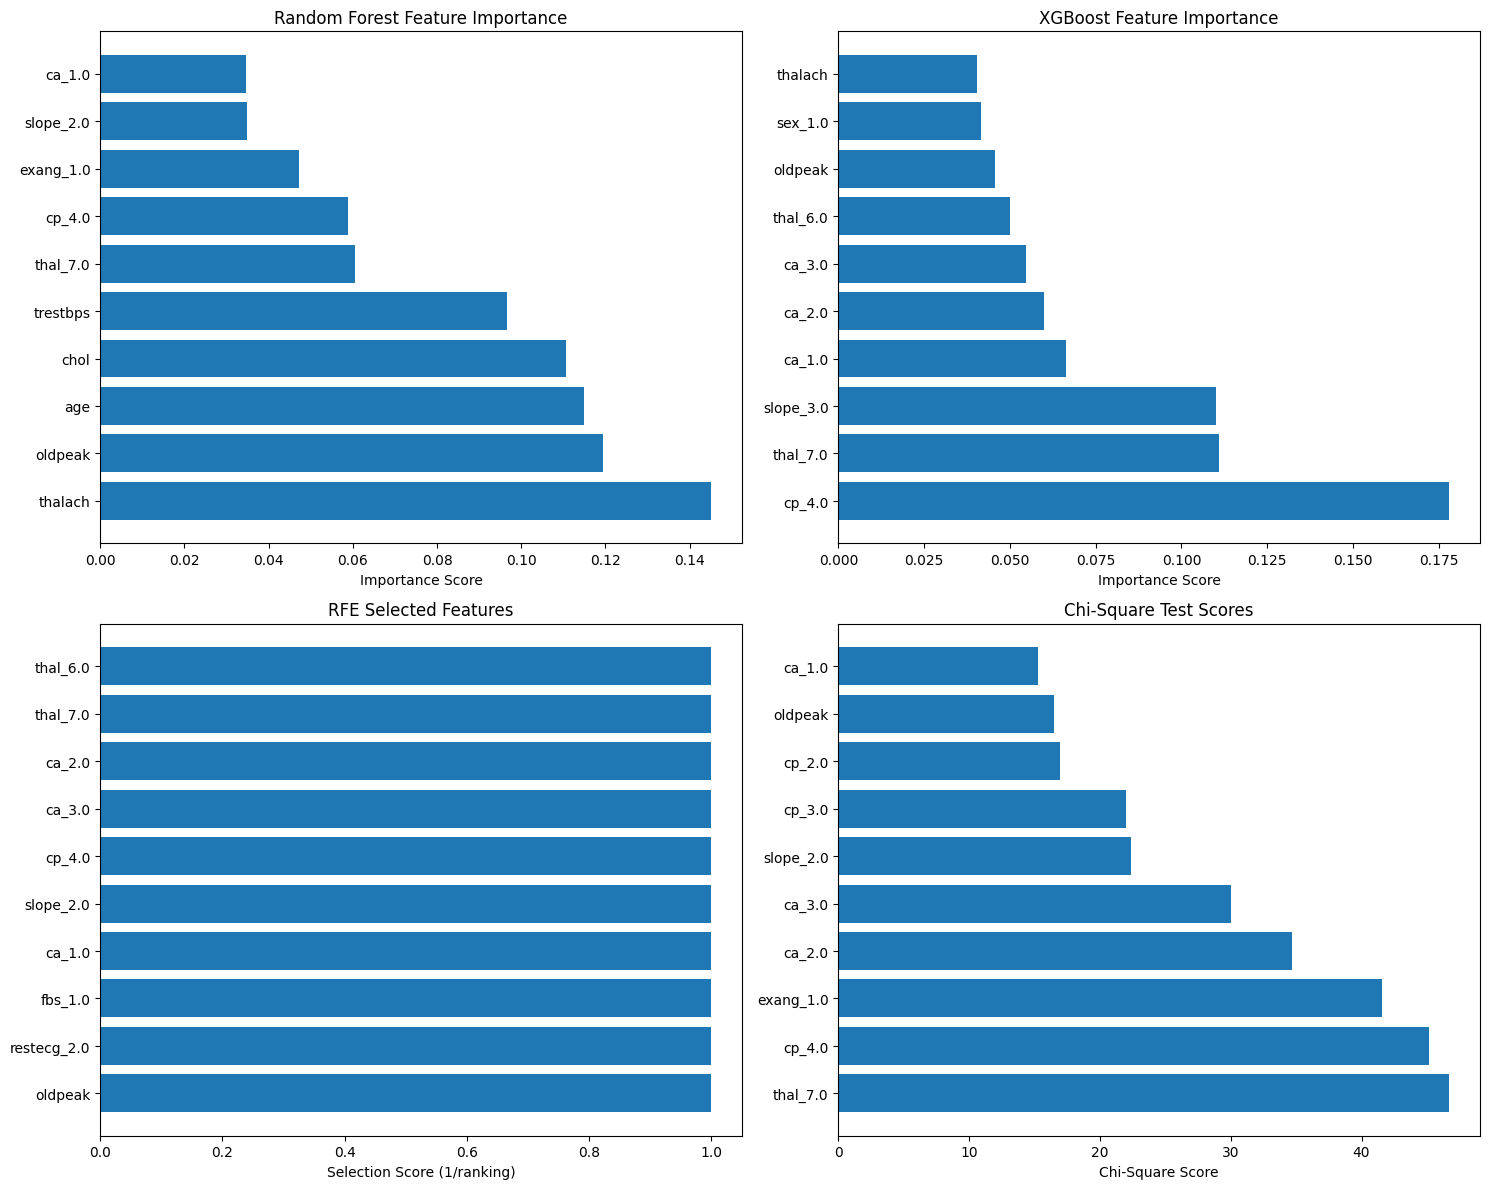

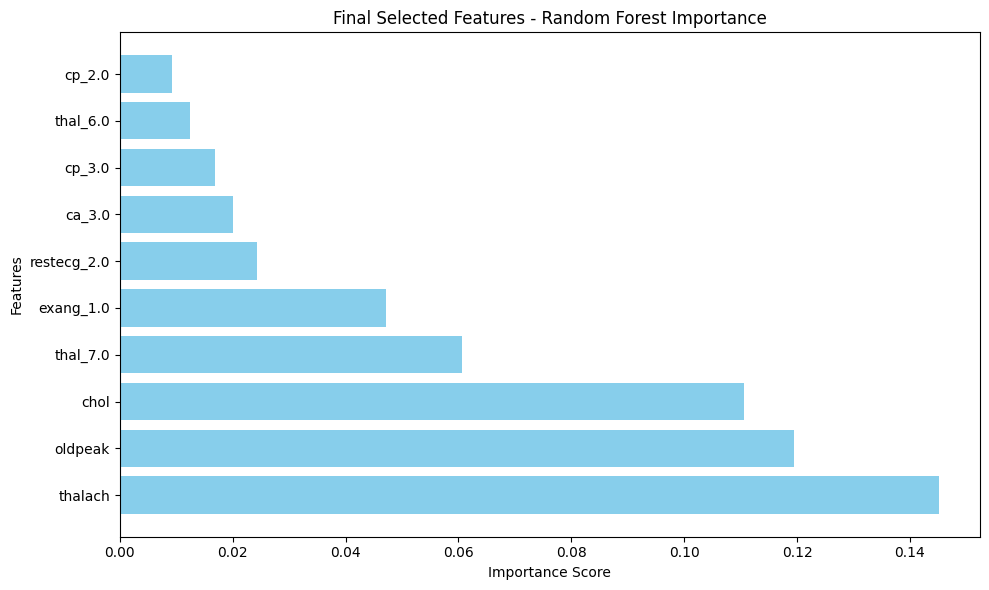

Final selected features: 10 features
1. chol
2. oldpeak
3. cp_2.0
4. thal_6.0
5. thalach
6. cp_3.0
7. exang_1.0
8. ca_3.0
9. restecg_2.0
10. thal_7.0
Feature Selection - X_train: (242, 10), X_test: (61, 10)


In [1]:
%run " 03_feature_selection.ipynb"

from sklearn.model_selection import train_test_split
X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(X_selected, y, test_size=0.2, random_state=42, stratify=y)

print(f"Feature Selection - X_train: {X_train_fs.shape}, X_test: {X_test_fs.shape}")

# GridSearchCV - Feature Selection

In [2]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import joblib
import numpy as np

param_grids = {
    'Logistic Regression': {'C': [0.1, 1, 10], 'max_iter': [1000]},
    'Decision Tree': {'max_depth': [3, 5, 10], 'min_samples_split': [2, 5, 10]},
    'Random Forest': {'n_estimators': [50, 100], 'max_depth': [3, 5, 10]},
    'SVM': {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear']}
}

models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

best_models_fs = {}
for name, model in models.items():
    grid_search = GridSearchCV(model, param_grids[name], cv=5, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train_fs, y_train_fs)
    best_models_fs[name] = grid_search.best_estimator_
    joblib.dump(grid_search.best_estimator_, f'/workspaces/Heart-Disease-Project/results/best_{name.lower().replace(" ", "_")}_fs.pkl')
    print(f"{name} - Best params: {grid_search.best_params_}")

Logistic Regression - Best params: {'C': 0.1, 'max_iter': 1000}
Decision Tree - Best params: {'max_depth': 5, 'min_samples_split': 10}
Random Forest - Best params: {'max_depth': 5, 'n_estimators': 50}
SVM - Best params: {'C': 1, 'kernel': 'rbf'}


# RandomizedSearchCV - Feature Selection

In [3]:
random_param_grids = {
    'Logistic Regression': {'C': [0.01, 0.1, 1, 10, 100], 'max_iter': [500, 1000, 2000]},
    'Decision Tree': {'max_depth': [3, 5, 7, 10, 15], 'min_samples_split': [2, 5, 10, 15]},
    'Random Forest': {'n_estimators': [50, 100, 200], 'max_depth': [3, 5, 7, 10], 'min_samples_split': [2, 5, 10]},
    'SVM': {'C': [0.01, 0.1, 1, 10, 100], 'kernel': ['rbf', 'linear', 'poly']}
}

best_models_random_fs = {}
for name, model in models.items():
    random_search = RandomizedSearchCV(model, random_param_grids[name], cv=5, scoring='accuracy', n_iter=10, random_state=42, n_jobs=-1)
    random_search.fit(X_train_fs, y_train_fs)
    best_models_random_fs[name] = random_search.best_estimator_
    joblib.dump(random_search.best_estimator_, f'/workspaces/Heart-Disease-Project/results/best_random_{name.lower().replace(" ", "_")}_fs.pkl')
    print(f"{name} Random - Best params: {random_search.best_params_}")

Logistic Regression Random - Best params: {'max_iter': 2000, 'C': 0.1}
Decision Tree Random - Best params: {'min_samples_split': 15, 'max_depth': 7}
Random Forest Random - Best params: {'n_estimators': 200, 'min_samples_split': 10, 'max_depth': 7}
SVM Random - Best params: {'kernel': 'poly', 'C': 1}


# Load PCA Data

(303, 14)
Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Total missing values: 6
Missing values after imputation: 0
Categorical columns: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Data types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target      float64
dtype: object
Categorical columns: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Numerical columns: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Shape after encoding: (303, 21)
New columns created:
['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target', 'sex_1.0', 'cp_2.0', 'cp_3.0', 'cp_4

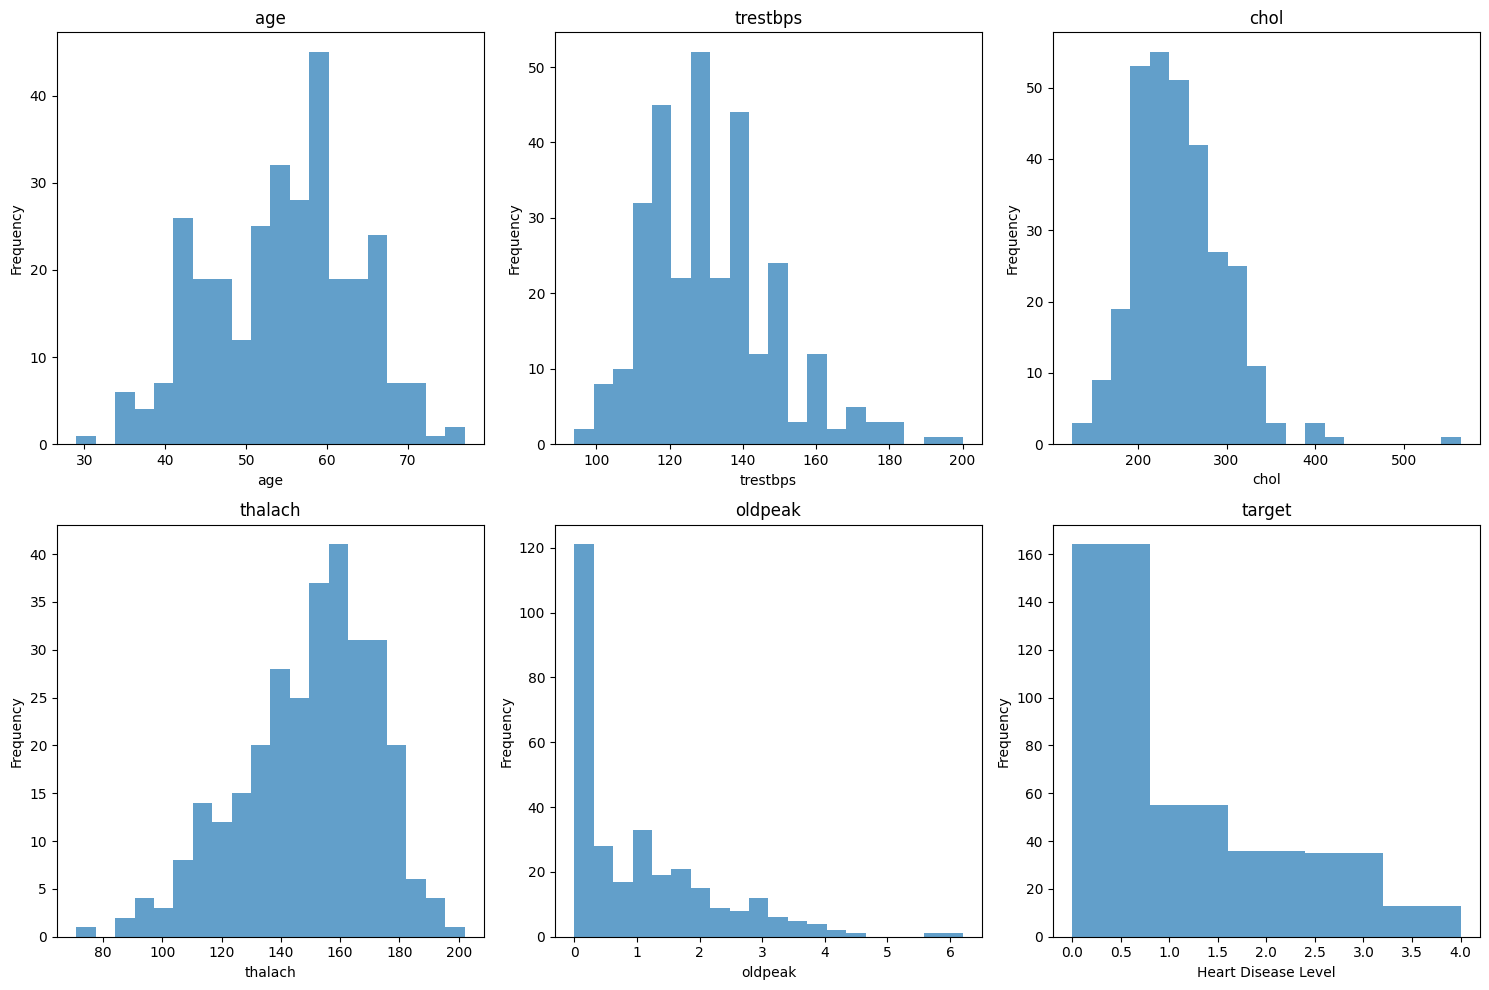

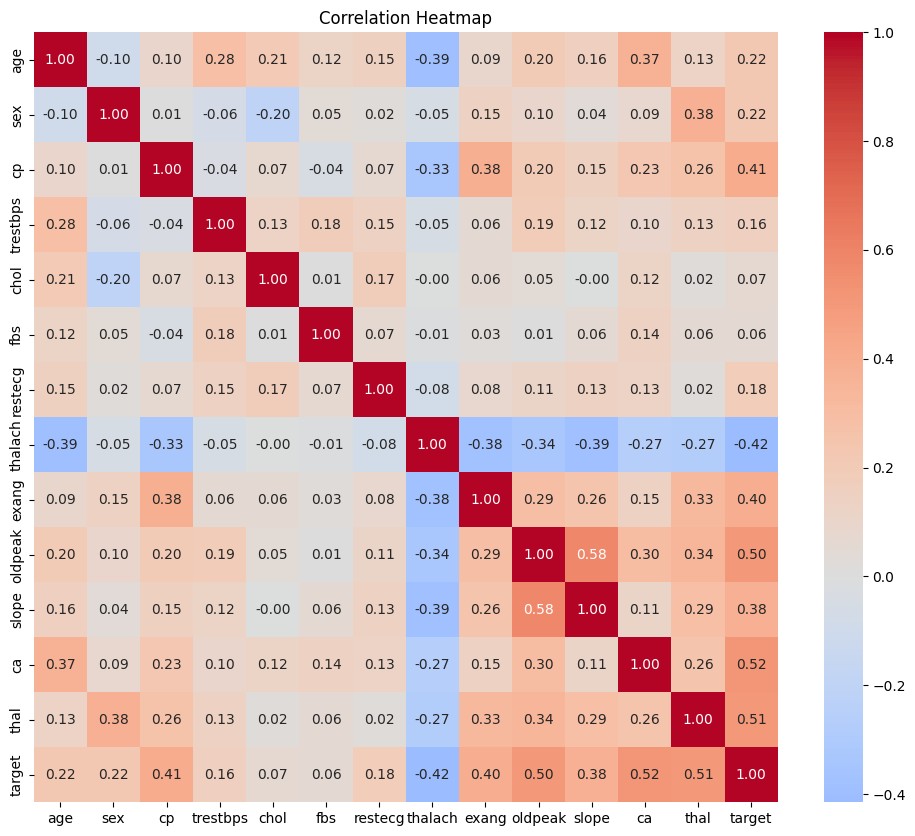

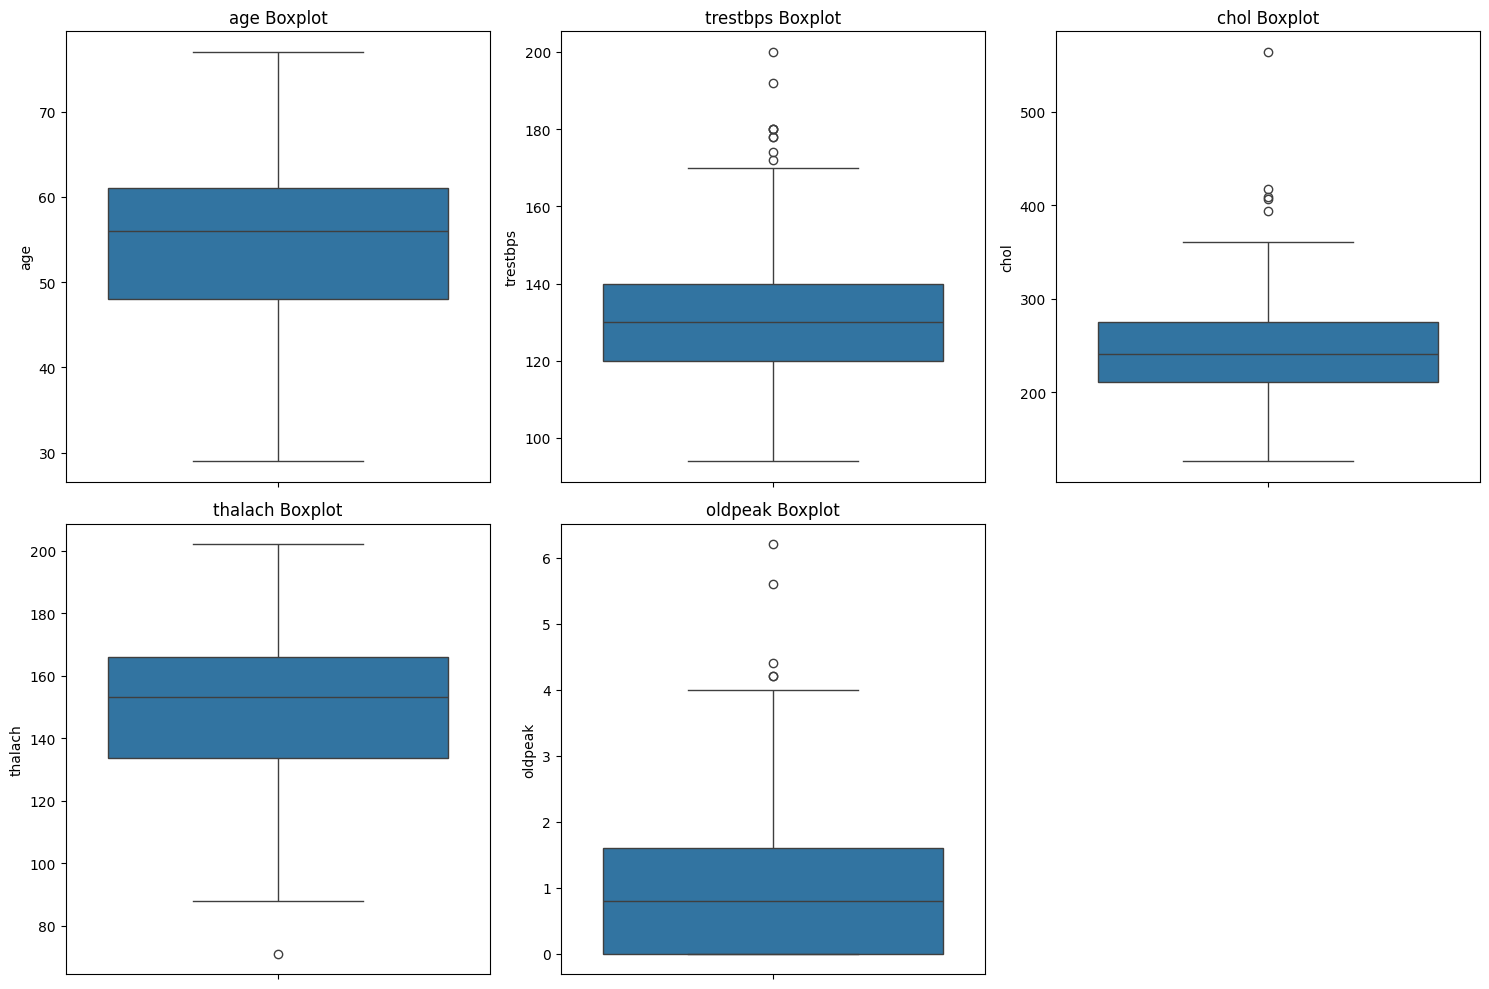

Standardized features shape: (303, 20)
Number of features: 20
Target shape: (303,)
PCA-transformed dataset shape: (303, 20)
Number of components: 20
Explained variance ratio per component:
PC1: 0.2673
PC2: 0.1574
PC3: 0.1215
PC4: 0.1080
PC5: 0.0696
PC6: 0.0480
PC7: 0.0349
PC8: 0.0326
PC9: 0.0283
PC10: 0.0252

Cumulative variance explained by first 10 components: 0.8928
Components needed for 95% variance: 13
Components needed for 90% variance: 11
Variance explained by 13 components: 0.9514
Variance explained by 11 components: 0.9151


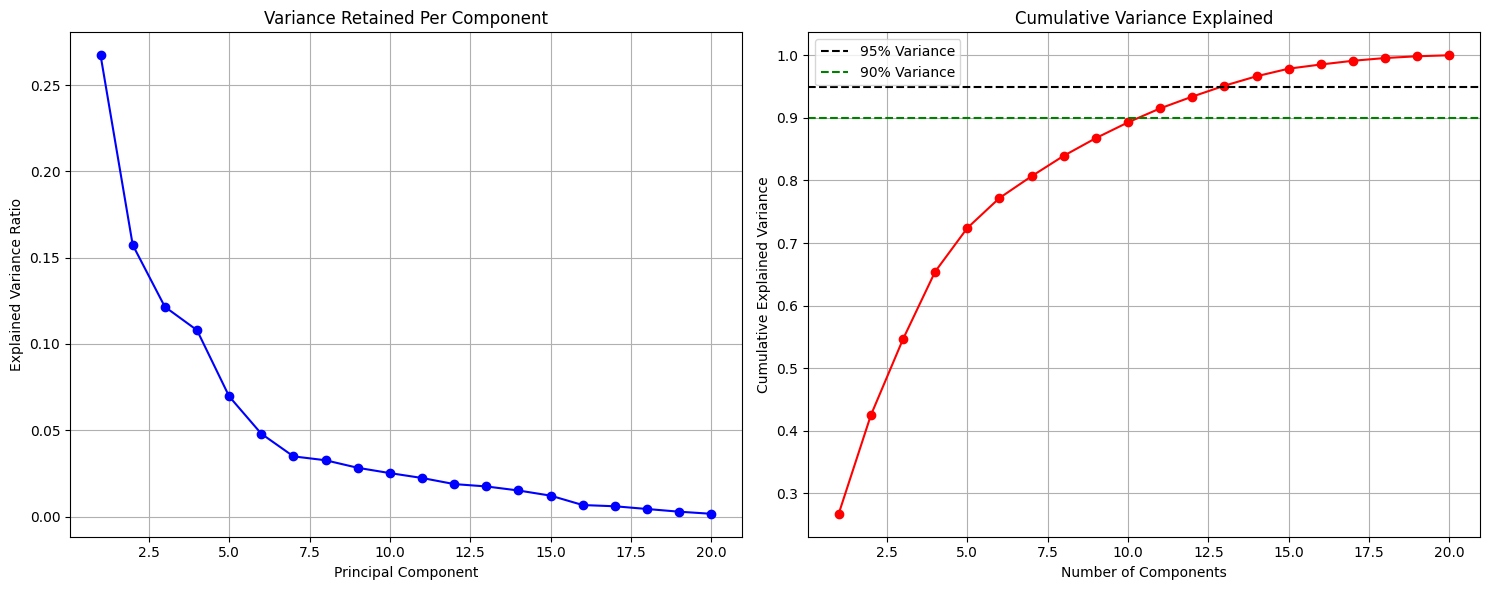

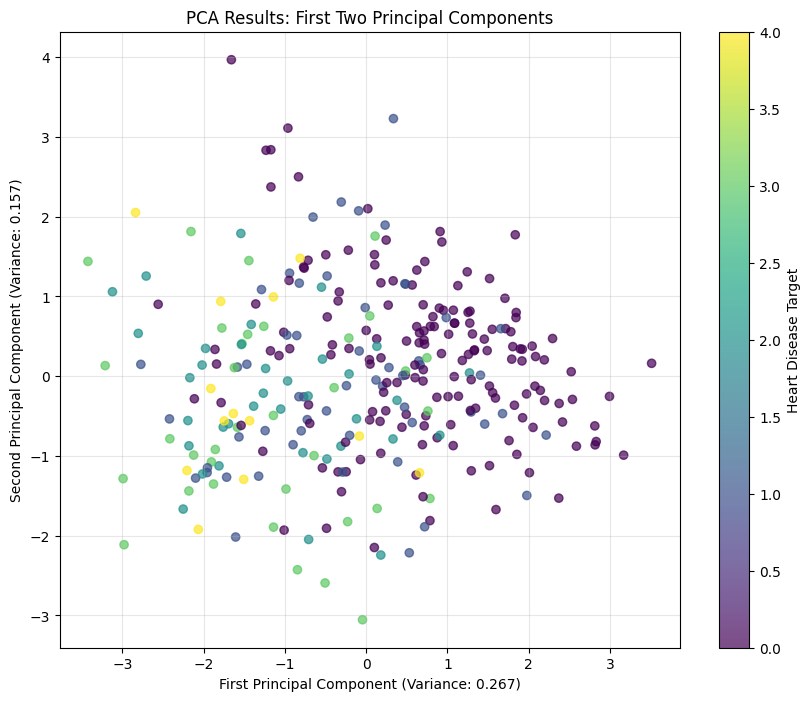

PCA-transformed dataset shape: (303, 14)
Variance retained: 0.9514

PCA-transformed dataset:
        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0 -1.072490  0.258394  1.037182 -0.119774  0.953289 -0.168047 -0.151114   
1 -2.804616  0.536802  0.003767 -0.617366 -0.979691 -0.090323 -0.259099   
2 -1.957112 -1.208116 -0.428867  0.056204  0.846473  0.874964 -0.066097   
3  1.135660 -0.251109  1.406952  2.691248  1.082938 -0.893851  0.210580   
4  1.591257 -0.273598  0.984122  0.735972  0.129932 -0.368240 -0.827301   

        PC8       PC9      PC10      PC11      PC12      PC13  target  
0  0.520553 -1.032009 -0.042051 -0.232873  0.586556  0.101403     0.0  
1  0.358687 -0.161476  0.112805 -0.161623  0.408115  0.413059     2.0  
2  0.304299  0.241857  0.124506 -0.386049  0.130411 -0.373702     1.0  
3 -0.248456 -0.390239 -0.400314  0.143627  0.169677  0.383118     0.0  
4  0.489760 -0.393350  0.433480  0.376107 -0.391069 -0.582531     0.0  
PCA - X_train: (242, 13)

In [5]:
%run "02_pca_analysis.ipynb"

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca_optimal, y, test_size=0.2, random_state=42, stratify=y)

print(f"PCA - X_train: {X_train_pca.shape}, X_test: {X_test_pca.shape}")

# GridSearchCV - PCA

In [6]:
best_models_pca = {}
for name, model in models.items():
    grid_search = GridSearchCV(model, param_grids[name], cv=5, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train_pca, y_train_pca)
    best_models_pca[name] = grid_search.best_estimator_
    joblib.dump(grid_search.best_estimator_, f'/workspaces/Heart-Disease-Project/results/best_{name.lower().replace(" ", "_")}_pca.pkl')
    print(f"{name} PCA - Best params: {grid_search.best_params_}")

Logistic Regression PCA - Best params: {'C': 0.1, 'max_iter': 1000}
Decision Tree PCA - Best params: {'max_depth': 5, 'min_samples_split': 10}
Random Forest PCA - Best params: {'max_depth': 10, 'n_estimators': 50}
Random Forest PCA - Best params: {'max_depth': 10, 'n_estimators': 50}
SVM PCA - Best params: {'C': 1, 'kernel': 'linear'}
SVM PCA - Best params: {'C': 1, 'kernel': 'linear'}


# RandomizedSearchCV - PCA

In [7]:
best_models_pca_random = {}
for name, model in models.items():
    random_search = RandomizedSearchCV(model, random_param_grids[name], cv=5, 
                                     scoring='accuracy', n_jobs=-1, n_iter=50, random_state=42)
    random_search.fit(X_train_pca, y_train_pca)
    best_models_pca_random[name] = random_search.best_estimator_
    joblib.dump(random_search.best_estimator_, f'/workspaces/Heart-Disease-Project/results/best_{name.lower().replace(" ", "_")}_pca_random.pkl')
    print(f"{name} PCA Random - Best params: {random_search.best_params_}")

/home/codespace/.local/lib/python3.12/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 15 is smaller than n_iter=50. Running 15 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Logistic Regression PCA Random - Best params: {'max_iter': 500, 'C': 0.1}


/home/codespace/.local/lib/python3.12/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 20 is smaller than n_iter=50. Running 20 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Decision Tree PCA Random - Best params: {'min_samples_split': 10, 'max_depth': 5}


/home/codespace/.local/lib/python3.12/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 36 is smaller than n_iter=50. Running 36 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Random Forest PCA Random - Best params: {'n_estimators': 200, 'min_samples_split': 5, 'max_depth': 7}


/home/codespace/.local/lib/python3.12/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 15 is smaller than n_iter=50. Running 15 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


SVM PCA Random - Best params: {'kernel': 'linear', 'C': 1}


# Model Evaluation and Comparison

In [8]:
def evaluate_models(models_dict, X_test, y_test, data_type=""):
    """Evaluate models and return results dictionary"""
    results = {}
    
    for name, model in models_dict.items():
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)
        
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')
        roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
        
        results[f"{name}{data_type}"] = {
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1,
            'ROC-AUC': roc_auc
        }
    
    return results

In [12]:
# Evaluate all optimized models
print("Evaluating GridSearchCV models...")
grid_results_fs = evaluate_models(best_models_fs, X_test_fs, y_test_fs, " (GridSearchCV-FS)")
grid_results_pca = evaluate_models(best_models_pca, X_test_pca, y_test_pca, " (GridSearchCV-PCA)")

print("Evaluating RandomizedSearchCV models...")
random_results_fs = evaluate_models(best_models_random_fs, X_test_fs, y_test_fs, " (RandomSearchCV-FS)")
random_results_pca = evaluate_models(best_models_pca_random, X_test_pca, y_test_pca, " (RandomSearchCV-PCA)")

# Combine all results
all_results = {}
all_results.update(grid_results_fs)
all_results.update(grid_results_pca)
all_results.update(random_results_fs)
all_results.update(random_results_pca)

Evaluating GridSearchCV models...
Evaluating RandomizedSearchCV models...


In [13]:
# Create comprehensive results DataFrame
results_df = pd.DataFrame.from_dict(all_results, orient='index')
results_df = results_df.round(4)

print("\n=== HYPERPARAMETER TUNING RESULTS ===")
print(results_df)

# Find best performing models
print(f"\nBest Accuracy: {results_df['Accuracy'].max():.4f}")
print(f"Best F1-Score: {results_df['F1-Score'].max():.4f}")
print(f"Best ROC-AUC: {results_df['ROC-AUC'].max():.4f}")

best_accuracy_model = results_df['Accuracy'].idxmax()
print(f"\nBest Overall Model (by accuracy): {best_accuracy_model}")
print(f"Performance: {results_df.loc[best_accuracy_model].to_dict()}")


=== HYPERPARAMETER TUNING RESULTS ===
                                          Accuracy  Precision  Recall  \
Logistic Regression (GridSearchCV-FS)       0.6230     0.5203  0.6230   
Decision Tree (GridSearchCV-FS)             0.5082     0.4321  0.5082   
Random Forest (GridSearchCV-FS)             0.5410     0.4098  0.5410   
SVM (GridSearchCV-FS)                       0.5410     0.3798  0.5410   
Logistic Regression (GridSearchCV-PCA)      0.5738     0.4475  0.5738   
Decision Tree (GridSearchCV-PCA)            0.4754     0.5039  0.4754   
Random Forest (GridSearchCV-PCA)            0.5574     0.4208  0.5574   
SVM (GridSearchCV-PCA)                      0.6230     0.5715  0.6230   
Logistic Regression (RandomSearchCV-FS)     0.6230     0.5203  0.6230   
Decision Tree (RandomSearchCV-FS)           0.4918     0.3871  0.4918   
Random Forest (RandomSearchCV-FS)           0.5410     0.4190  0.5410   
SVM (RandomSearchCV-FS)                     0.5410     0.3944  0.5410   
Logistic Reg

In [14]:
# Save comprehensive results
results_df.to_csv('/workspaces/Heart-Disease-Project/results/hyperparameter_tuning_results.csv')

# Update evaluation metrics file
with open('/workspaces/Heart-Disease-Project/results/evaluation_metrics.txt', 'a') as f:
    f.write("\n\n=== HYPERPARAMETER TUNING RESULTS ===\n")
    f.write(f"Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
    f.write("Optimized Model Performance:\n")
    f.write(results_df.to_string())
    f.write(f"\n\nBest Overall Model: {best_accuracy_model}\n")
    f.write(f"Best Accuracy: {results_df['Accuracy'].max():.4f}\n")
    f.write(f"Best F1-Score: {results_df['F1-Score'].max():.4f}\n")
    f.write(f"Best ROC-AUC: {results_df['ROC-AUC'].max():.4f}\n")

print("Results saved to hyperparameter_tuning_results.csv")
print("Evaluation metrics file updated with optimized results")

Results saved to hyperparameter_tuning_results.csv
Evaluation metrics file updated with optimized results


# Visualization of Results

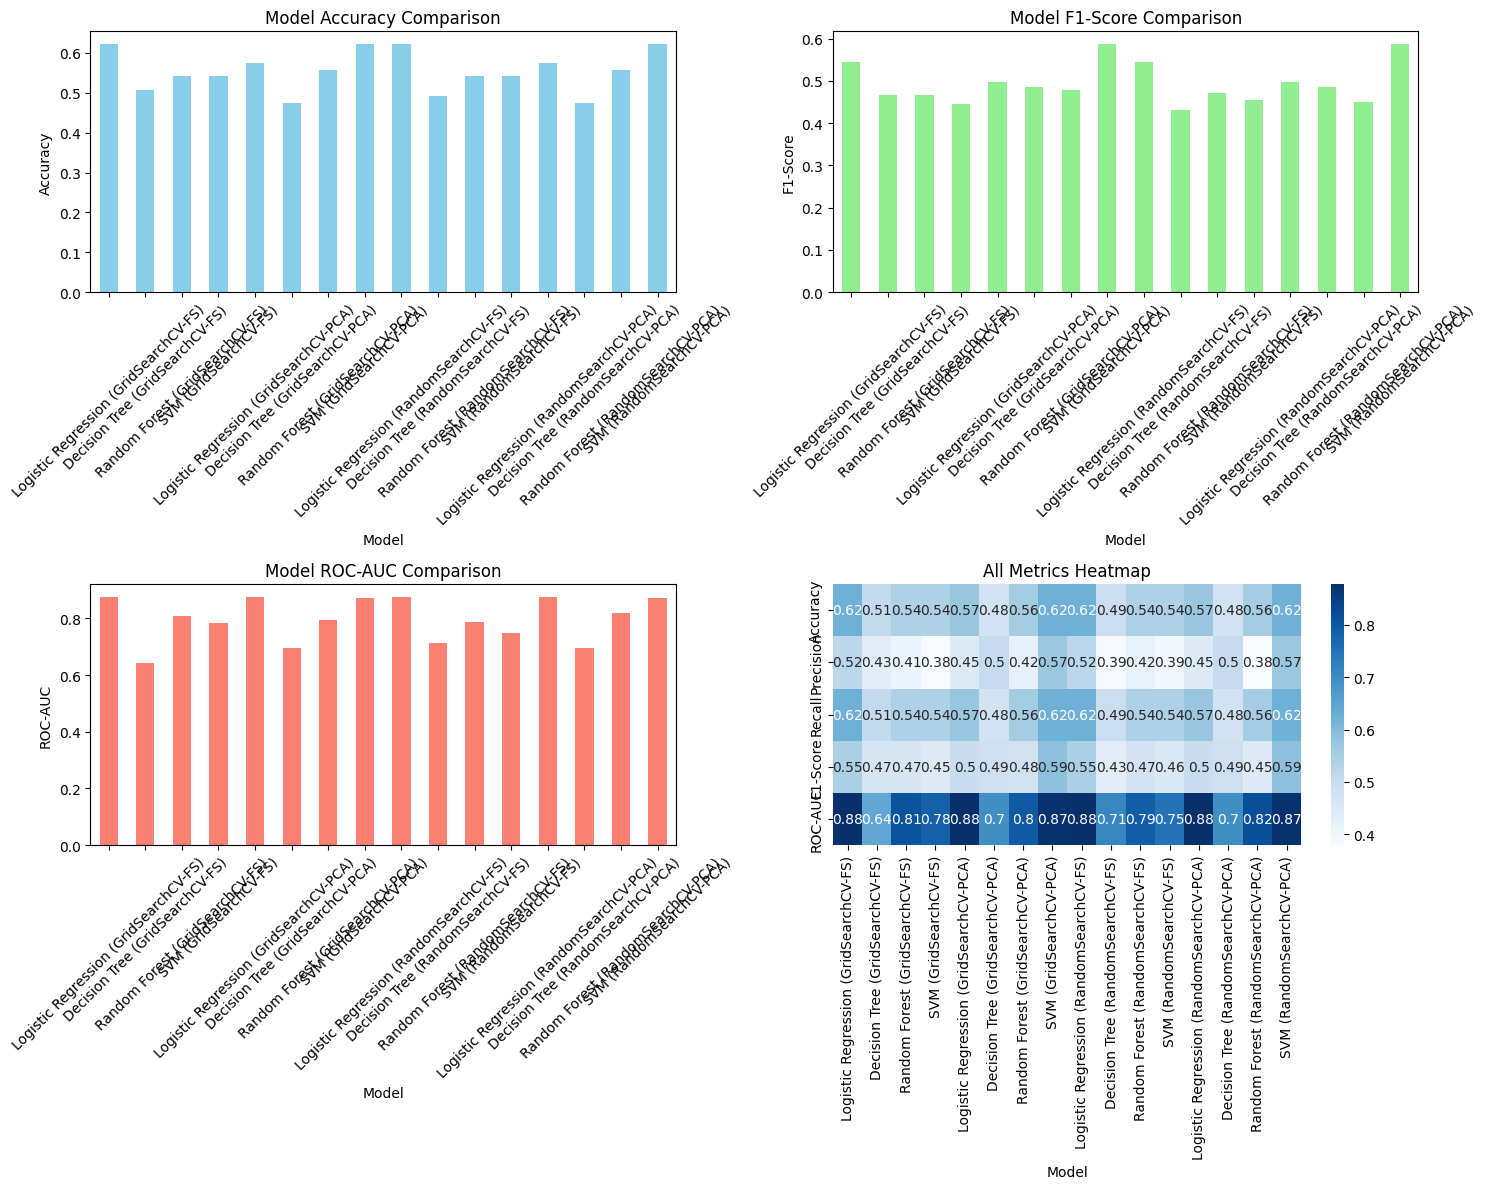

In [15]:
# Create visualization comparing all models
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Accuracy comparison
results_df['Accuracy'].plot(kind='bar', ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Model Accuracy Comparison')
axes[0,0].set_xlabel('Model')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].tick_params(axis='x', rotation=45)

# F1-Score comparison
results_df['F1-Score'].plot(kind='bar', ax=axes[0,1], color='lightgreen')
axes[0,1].set_title('Model F1-Score Comparison')
axes[0,1].set_xlabel('Model')
axes[0,1].set_ylabel('F1-Score')
axes[0,1].tick_params(axis='x', rotation=45)

# ROC-AUC comparison
results_df['ROC-AUC'].plot(kind='bar', ax=axes[1,0], color='salmon')
axes[1,0].set_title('Model ROC-AUC Comparison')
axes[1,0].set_xlabel('Model')
axes[1,0].set_ylabel('ROC-AUC')
axes[1,0].tick_params(axis='x', rotation=45)

# Overall metrics heatmap
sns.heatmap(results_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].T, 
            annot=True, cmap='Blues', ax=axes[1,1])
axes[1,1].set_title('All Metrics Heatmap')
axes[1,1].set_xlabel('Model')

plt.tight_layout()
plt.savefig('/workspaces/Heart-Disease-Project/results/hyperparameter_tuning_comparison.png', 
            dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Save Best Model and Pipeline

In [16]:
import joblib
import pickle
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Determine which dataset the best model was trained on
best_model_name = best_accuracy_model
is_pca = 'PCA' in best_model_name
is_fs = 'FS' in best_model_name

# Get the best model object
if 'GridSearchCV' in best_model_name:
    if is_pca:
        best_model_obj = best_models_pca[best_model_name.split(' (GridSearchCV-PCA)')[0]]
    else:
        best_model_obj = best_models_fs[best_model_name.split(' (GridSearchCV-FS)')[0]]
else:  # RandomizedSearchCV
    if is_pca:
        best_model_obj = best_models_pca_random[best_model_name.split(' (RandomSearchCV-PCA)')[0]]
    else:
        best_model_obj = best_models_random_fs[best_model_name.split(' (RandomSearchCV-FS)')[0]]

print(f"Best model: {best_model_name}")
print(f"Model type: {type(best_model_obj).__name__}")
print(f"Model parameters: {best_model_obj.get_params()}")

# Save the best model
joblib.dump(best_model_obj, '/workspaces/Heart-Disease-Project/results/best_overall_model.pkl')
print("✓ Best model saved as best_overall_model.pkl")

Best model: Logistic Regression (GridSearchCV-FS)
Model type: LogisticRegression
Model parameters: {'C': 0.1, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}
✓ Best model saved as best_overall_model.pkl


In [ ]:
# Create and save complete preprocessing pipeline for reproducibility
# This ensures that the exact preprocessing steps can be replicated during inference

# Create appropriate preprocessing pipeline based on best model type
if is_pca:
    # For PCA approach: StandardScaler + PCA + Best Model
    preprocessing_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', pca_fs),  # Use the PCA transformer from feature selection notebook
        ('classifier', best_model_obj)
    ])
    pipeline_name = 'best_model_pipeline_pca.pkl'
    print("Creating PCA-based pipeline...")
    
    # Fit the complete pipeline on the training data
    preprocessing_pipeline.fit(X_train_fs, y_train_fs)
    
else:
    # For Feature Selection approach: StandardScaler + Feature Selection + Best Model  
    preprocessing_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', best_model_obj)
    ])
    pipeline_name = 'best_model_pipeline_feature_selection.pkl'
    print("Creating Feature Selection-based pipeline...")
    
    # Fit the complete pipeline on the selected features training data
    preprocessing_pipeline.fit(X_train_selected, y_train_selected)

# Save the complete pipeline
joblib.dump(preprocessing_pipeline, f'/workspaces/Heart-Disease-Project/results/{pipeline_name}')
print(f"✓ Complete preprocessing pipeline saved as {pipeline_name}")

# Also save feature selection information for the feature selection approach
if is_fs:
    feature_info = {
        'selected_features': selected_features,
        'selected_feature_names': [feature_names[i] for i in selected_features] if 'feature_names' in locals() else None,
        'feature_selection_method': 'Intersection of Random Forest, XGBoost, RFE, and Chi-Square'
    }
    joblib.dump(feature_info, '/workspaces/Heart-Disease-Project/results/selected_features_info.pkl')
    print("✓ Feature selection information saved as selected_features_info.pkl")

In [ ]:
# Test the saved pipeline to ensure it works correctly
print("\n=== Testing Saved Pipeline ===")

# Load the saved pipeline
loaded_pipeline = joblib.load(f'/workspaces/Heart-Disease-Project/results/{pipeline_name}')

# Make predictions on test data
if is_pca:
    test_predictions = loaded_pipeline.predict(X_test_fs)
    test_proba = loaded_pipeline.predict_proba(X_test_fs)
else:
    test_predictions = loaded_pipeline.predict(X_test_selected)
    test_proba = loaded_pipeline.predict_proba(X_test_selected)

# Calculate accuracy to verify pipeline works
test_accuracy = accuracy_score(y_test_selected if not is_pca else y_test_fs, test_predictions)
print(f"Loaded pipeline test accuracy: {test_accuracy:.4f}")

# Save model performance summary
model_summary = {
    'best_model_name': best_model_name,
    'best_model_accuracy': best_accuracy,
    'model_type': 'PCA-based' if is_pca else 'Feature Selection-based',
    'test_accuracy_verification': test_accuracy,
    'hyperparameter_method': 'GridSearchCV' if 'GridSearchCV' in best_model_name else 'RandomizedSearchCV',
    'model_parameters': best_model_obj.get_params(),
    'saved_files': [
        'best_overall_model.pkl',
        pipeline_name,
        'selected_features_info.pkl' if is_fs else 'pca_components_info.pkl'
    ]
}

# Save summary
with open('/workspaces/Heart-Disease-Project/results/best_model_summary.txt', 'w') as f:
    f.write("=== BEST MODEL SUMMARY ===\n")
    f.write(f"Model Name: {model_summary['best_model_name']}\n")
    f.write(f"Validation Accuracy: {model_summary['best_model_accuracy']:.4f}\n")
    f.write(f"Test Accuracy: {model_summary['test_accuracy_verification']:.4f}\n")
    f.write(f"Model Type: {model_summary['model_type']}\n")
    f.write(f"Optimization Method: {model_summary['hyperparameter_method']}\n")
    f.write(f"\nModel Parameters:\n")
    for param, value in model_summary['model_parameters'].items():
        f.write(f"  {param}: {value}\n")
    f.write(f"\nSaved Files:\n")
    for file in model_summary['saved_files']:
        f.write(f"  - {file}\n")

print("✓ Model summary saved as best_model_summary.txt")
print("\n=== MODEL SAVING COMPLETE ===")
print("The following files have been saved:")
print("1. best_overall_model.pkl - The optimized model object")
print(f"2. {pipeline_name} - Complete preprocessing + model pipeline")
print("3. selected_features_info.pkl - Feature selection details (if applicable)")
print("4. best_model_summary.txt - Model performance and configuration summary")